# Hierarchical CRNN — joint detection + subtype, coupled by weight transfer

`model_stage1_cnn1d_detection.ipynb` and `model_stage2_cnn1d_subtype.ipynb` trained two
unrelated CNNs from scratch. `model_cascade_end_to_end.ipynb` only wired the two together
*after* training, at inference time — neither model's weights ever depended on the other.
This notebook builds what was actually asked for: **one model family**, a CRNN (1D-conv
feature extractor → bidirectional LSTM → attention pooling) whose subtype stage is never
trained from scratch — it starts from the backbone the detection stage already learned, on
both datasets pooled together, and fine-tunes from there.

## Design

**Two phases, one shared backbone class (`CRNNBackbone`):**

1. **Phase A — shared backbone pretraining.** A `CRNNBackbone` + detection head is trained
   on CHB-MIT + Siena pooled — every window that has a seizure/non-seizure label, which is
   every window in `stage1_windows.parquet`, both datasets. This is the representation the
   subtype stage inherits.
2. **Phase B — subtype fine-tuning via weight transfer.** For each Siena patient (LOSO —
   Siena's subtype label is essentially a per-patient attribute, see below), a fresh model is
   built with its backbone **initialized from Phase A's trained weights, not random init**,
   the earliest conv blocks are frozen, and the rest (later conv blocks, the LSTM, attention
   pooling, and a new subtype head) is fine-tuned on the other 12 patients.
3. **Phase C — end-to-end evaluation.** The two phases are wired into a single gated pipeline
   and scored the same honest way `model_cascade_end_to_end.ipynb` did, so this notebook's
   result is directly comparable to that one.

## Why not one joint loss end-to-end, instead of two phases?

True joint multi-task learning (one training loop, `loss = L_detect + λ·L_subtype` every
step) was considered and rejected. `manifest.json`'s `subtype_by_patient` shows Siena's
subtype label is patient-level, not event-level: 11 of 13 usable patients are
`focal_impaired_awareness`, one patient alone carries `focal_aware`, one alone carries
`focal_to_bilateral_tonic_clonic`. If the *shared* backbone were exposed to a patient's
subtype-labelled windows during pretraining, that patient's LOSO fold in Phase B would already
be leaking through the shared weights before fine-tuning even starts — Stage 2's own
adversarial-control experiment exists precisely because this kind of leakage is easy to miss
and inflates results without adding any real subtyping ability. Splitting into two phases
(detection-only pretraining, so no patient's subtype ever touches the shared weights up
front, followed by per-fold transfer) is what keeps LOSO honest while still making Stage 2
depend on Stage 1's weights rather than training independently — which is the actual point of
this notebook.

## Why a CRNN instead of the existing plain CNN?

The 1D CNN backbone (`SeizureCNN1D`/`SubtypeCNN1D`) reduces the window to a single pooled
vector via `AdaptiveAvgPool1d` — no explicit notion of *when* within the window something
happened. `CRNNBackbone` below keeps the conv stack's per-timestep feature sequence and feeds
it to a bidirectional LSTM, then an attention layer picks out which timesteps matter most
before collapsing to a fixed-size vector. Attention pooling has the same input-length-agnostic
property `AdaptiveAvgPool1d` gave the old backbones — useful here since Stage 1 windows are
4 s / 1024 samples and Stage 2 windows are 10 s / 2560 samples, and **the same backbone
instance processes both without modification**, which is exactly what weight transfer between
the two stages requires.

## Datasets

CHB-MIT scalp EEG + Siena Scalp EEG (both PhysioNet), same harmonized 18-channel bipolar
windows `preprocessing.ipynb` built — nothing here reads raw EDF.

## Config

The only cell meant to be edited between runs.

In [22]:
import copy
import json
import warnings
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                              roc_auc_score, roc_curve)

warnings.filterwarnings("ignore")
plt.rcParams["figure.facecolor"] = "white"

# ---- paths --------------------------------------------------------------------------
WIN_ROOT = Path("../data/harmonized/windows")
CKPT_DIR = Path("../checkpoints/crnn_hierarchical")
PHASE_B_CKPT_DIR = CKPT_DIR / "phase_b_loso"
CKPT_DIR.mkdir(parents=True, exist_ok=True)
PHASE_B_CKPT_DIR.mkdir(parents=True, exist_ok=True)

# ---- reproducibility ------------------------------------------------------------------
SEED = 20260803                                     # same seed as every other notebook in this repo

# ---- split (Phase A) -------------------------------------------------------------------
TRAIN_FRAC, VAL_FRAC = 0.70, 0.15                   # remainder -> test; split is per-subject

# ---- data volume per epoch (Phase A) ---------------------------------------------------
BATCH_SIZE = 64
TRAIN_STEPS_PER_EPOCH = 300                         # -> TRAIN_STEPS_PER_EPOCH * BATCH_SIZE windows/epoch
VAL_SAMPLE_SIZE = 8000
TEST_EVAL_MAX_SAMPLES = 15000

# ---- backbone (shared between Phase A and Phase B) --------------------------------------
CNN_WIDTH = 32                                      # matches Stage 1's MODEL_WIDTH
RNN_HIDDEN = 64                                      # backbone output = 2 * RNN_HIDDEN (bidirectional)
RNN_LAYERS = 1
CNN_DROPOUT = 0.1
RNN_DROPOUT = 0.2

# ---- Phase A optimization ---------------------------------------------------------------
PHASE_A_HEAD_DROPOUT = 0.35                         # matches Stage 1's DROPOUT
PHASE_A_LR = 1e-3
PHASE_A_WEIGHT_DECAY = 3e-4
PHASE_A_EPOCHS = 25
PHASE_A_PATIENCE = 10
FOCAL_ALPHA = 0.5                                   # WeightedRandomSampler already balances batches;
FOCAL_GAMMA = 2.0                                   # alpha=0.5 avoids double-correcting on top of it (Stage 1 finding)

# ---- Phase B optimization (per LOSO fold) ------------------------------------------------
PHASE_B_HEAD_DROPOUT = 0.5                          # matches Stage 2's DROPOUT -- small per-fold data, more regularization
FREEZE_CONV_BLOCKS = 2                              # freeze the first 2 of 4 conv blocks; fine-tune the rest + LSTM + head
PHASE_B_LR = 3e-4                                   # lower than Phase A -- fine-tuning, not training from scratch
PHASE_B_WEIGHT_DECAY = 3e-3                          # matches Stage 2
PHASE_B_BATCH_SIZE = 32
PHASE_B_MAX_EPOCHS = 60
PHASE_B_PATIENCE = 10
PHASE_B_MIN_EPOCHS = 12                             # floor before early stopping can trigger -- see Stage 2's reasoning
CONTROL_WINDOWS_PER_PATIENT = 150                   # adversarial control set size, matches Stage 2

torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {DEVICE}" + (f" ({torch.cuda.get_device_name(0)})" if DEVICE.type == "cuda" else ""))

device: cuda (NVIDIA GeForce RTX 5060 Ti)


## Data

Loads the same harmonized window manifest every other model notebook uses. `S1` (detection,
928,154 windows, both datasets) drives Phase A. `S2` (subtype, 1,824 windows, Siena only)
drives Phase B.

In [23]:
S1 = pd.read_parquet(WIN_ROOT / "stage1_windows.parquet")
S2 = pd.read_parquet(WIN_ROOT / "stage2_windows.parquet")
MANIFEST = json.loads((WIN_ROOT / "manifest.json").read_text())

N_CH = MANIFEST["n_channels"]
N1_TIMEPOINTS = int(round(MANIFEST["stage1"]["window_s"] * MANIFEST["sfreq"]))
N2_TIMEPOINTS = int(round(MANIFEST["stage2"]["window_s"] * MANIFEST["sfreq"]))
CLASS_NAMES = MANIFEST["stage2"]["class_names"]
CLASS_TO_IDX = MANIFEST["stage2"]["class_to_idx"]
SUBTYPE_BY_PATIENT = MANIFEST["subtype_by_patient"]
N_CLASSES = len(CLASS_NAMES)

print(f"Stage 1: {len(S1):,} windows | {N1_TIMEPOINTS} samples ({MANIFEST['stage1']['window_s']:.0f}s)")
print(S1.groupby("dataset").label.value_counts().unstack(fill_value=0))
print(f"\nStage 2: {len(S2):,} windows | {N2_TIMEPOINTS} samples ({MANIFEST['stage2']['window_s']:.0f}s)")
print(S2.subtype.value_counts())
print("\npatients per class:"); print(S2.groupby("subtype").subject.nunique())

Stage 1: 928,154 windows | 1024 samples (4s)
label            0     1
dataset                 
CHB-MIT     800731  8732
SienaScalp  114489  4202

Stage 2: 1,824 windows | 2560 samples (10s)
subtype
focal_impaired_awareness           1655
focal_to_bilateral_tonic_clonic     124
focal_aware                          45
Name: count, dtype: int64

patients per class:
subtype
focal_aware                         1
focal_impaired_awareness           11
focal_to_bilateral_tonic_clonic     1
Name: subject, dtype: int64


### Subject-level, dataset-stratified split

Identical to `model_stage1_cnn1d_detection.ipynb`'s split, same seed — reused here (not
re-derived) so Phase A's train/val/test role for a given Siena patient is deterministic and
can be cross-referenced against that patient's Phase B LOSO fold in Phase C below, the same
"strict vs. broad" honesty check `model_cascade_end_to_end.ipynb` used.

In [24]:
def subject_split(df, train_frac, val_frac, seed):
    rng = np.random.default_rng(seed)
    train_s, val_s, test_s = set(), set(), set()
    for dataset, g in df.groupby("dataset"):
        subs = rng.permutation(sorted(g.subject_key.unique()))
        n = len(subs)
        n_train = max(1, int(round(n * train_frac)))
        n_val = max(1, int(round(n * val_frac)))
        train_s.update(subs[:n_train])
        val_s.update(subs[n_train:n_train + n_val])
        test_s.update(subs[n_train + n_val:])
    assert not (train_s & val_s) and not (train_s & test_s) and not (val_s & test_s), \
        "subject leakage across splits"
    return train_s, val_s, test_s

train_subj, val_subj, test_subj = subject_split(S1, TRAIN_FRAC, VAL_FRAC, SEED)

train_df = S1[S1.subject_key.isin(train_subj)].reset_index(drop=True)
val_df = S1[S1.subject_key.isin(val_subj)].reset_index(drop=True)
test_df = S1[S1.subject_key.isin(test_subj)].reset_index(drop=True)

for name, subs, df in [("train", train_subj, train_df), ("val", val_subj, val_df), ("test", test_subj, test_df)]:
    by_ds = pd.Series(sorted(subs)).str.split("/").str[0].value_counts()
    print(f"{name:5s}: {len(subs):2d} subjects ({dict(by_ds)}) | {len(df):,} windows | "
          f"{int((df.label == 1).sum()):,} seizure")

stage2_patients = sorted(S2.subject.unique())
def phase_a_role(subject_key):
    if subject_key in test_subj: return "test (unseen by Phase A)"
    if subject_key in val_subj: return "val (Phase A early-stop signal)"
    return "train (fully seen by Phase A)"
patient_roles = {p: phase_a_role(f"SienaScalp/{p}") for p in stage2_patients}
strict_patients = [p for p, r in patient_roles.items() if r.startswith("test")]
print(f"\nPhase-A role for each Phase-B (LOSO) patient:")
for p in stage2_patients:
    print(f"  {p}: {patient_roles[p]}")
print(f"\nstrict doubly-held-out set (unseen by Phase A AND the LOSO test fold): {strict_patients}")

train: 27 subjects ({'CHB-MIT': np.int64(17), 'SienaScalp': np.int64(10)}) | 693,155 windows | 9,017 seizure
val  :  6 subjects ({'CHB-MIT': np.int64(4), 'SienaScalp': np.int64(2)}) | 161,829 windows | 1,747 seizure
test :  5 subjects ({'CHB-MIT': np.int64(3), 'SienaScalp': np.int64(2)}) | 73,170 windows | 2,170 seizure

Phase-A role for each Phase-B (LOSO) patient:
  PN00: train (fully seen by Phase A)
  PN01: train (fully seen by Phase A)
  PN03: train (fully seen by Phase A)
  PN05: train (fully seen by Phase A)
  PN06: train (fully seen by Phase A)
  PN07: train (fully seen by Phase A)
  PN09: train (fully seen by Phase A)
  PN10: train (fully seen by Phase A)
  PN12: train (fully seen by Phase A)
  PN13: val (Phase A early-stop signal)
  PN14: val (Phase A early-stop signal)
  PN16: test (unseen by Phase A)
  PN17: test (unseen by Phase A)

strict doubly-held-out set (unseen by Phase A AND the LOSO test fold): ['PN16', 'PN17']


## Dataset

Same lazy HDF5 read + per-channel z-score normalization every notebook in this repo uses.
`num_workers=0` throughout — PyTorch's multiprocessing `DataLoader` workers don't reliably
re-import a running notebook as `__main__` under Windows + Jupyter, so single-process loading
is deliberate, not an oversight (see Stage 1's Dataset section for the same note).

In [25]:
class WindowDataset(Dataset):
    def __init__(self, df, n_timepoints, label_col="label", label_dtype=torch.float32, augment=False):
        self.rows = df.reset_index(drop=True)
        self.n_timepoints = n_timepoints
        self.label_col = label_col
        self.label_dtype = label_dtype
        self.augment = augment
        self._cache = {}

    def __len__(self):
        return len(self.rows)

    def _file(self, path):
        f = self._cache.get(path)
        if f is None:
            f = h5py.File(path, "r")
            self._cache[path] = f
        return f

    def __getitem__(self, idx):
        row = self.rows.iloc[idx]
        sig = self._file(row.path)["signal"]
        start = int(row.start)
        end = min(start + self.n_timepoints, sig.shape[1])
        w = sig[:, start:end].astype(np.float32)
        if w.shape[1] < self.n_timepoints:
            w = np.pad(w, ((0, 0), (0, self.n_timepoints - w.shape[1])), mode="edge")
        mu = w.mean(axis=1, keepdims=True)
        sd = w.std(axis=1, keepdims=True) + 1e-6
        w = (w - mu) / sd
        if self.augment:
            w = w + np.random.normal(0.0, 0.02, size=w.shape).astype(np.float32)
        label = row[self.label_col]
        if self.label_dtype == torch.int64:
            label = CLASS_TO_IDX[label]
        return torch.from_numpy(w), torch.tensor(label, dtype=self.label_dtype)


def stratified_sample(df, n, seed, label_col="label"):
    pos = df[df[label_col] == 1]
    neg = df[df[label_col] == 0]
    n_pos = min(len(pos), n // 2)
    n_neg = min(len(neg), n - n_pos)
    parts = [d.sample(k, random_state=seed) for d, k in [(pos, n_pos), (neg, n_neg)] if k > 0]
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)


def weighted_sampler(df, n_samples, seed, label_col="label"):
    counts = df[label_col].value_counts()
    inv_freq = {c: 1.0 / n for c, n in counts.items()}
    weights = df[label_col].map(inv_freq).to_numpy()
    gen = torch.Generator().manual_seed(seed)
    return WeightedRandomSampler(weights, num_samples=n_samples, replacement=True, generator=gen)


def preload(df, n_timepoints, y_col, class_to_idx):
    X = np.empty((len(df), N_CH, n_timepoints), dtype=np.float32)
    y = np.empty(len(df), dtype=np.int64)
    cache = {}
    for i, row in enumerate(df.itertuples(index=False)):
        f = cache.get(row.path)
        if f is None:
            f = h5py.File(row.path, "r")
            cache[row.path] = f
        sig = f["signal"]
        start = int(row.start)
        end = min(start + n_timepoints, sig.shape[1])
        w = sig[:, start:end].astype(np.float32)
        if w.shape[1] < n_timepoints:
            w = np.pad(w, ((0, 0), (0, n_timepoints - w.shape[1])), mode="edge")
        mu = w.mean(axis=1, keepdims=True)
        sd = w.std(axis=1, keepdims=True) + 1e-6
        X[i] = (w - mu) / sd
        y[i] = class_to_idx[getattr(row, y_col)]
    for f in cache.values():
        f.close()
    return torch.from_numpy(X), torch.from_numpy(y)

print("dataset helpers ready")

dataset helpers ready


## Model — `CRNNBackbone` + two heads

`CRNNBackbone`: 4 `Conv1d -> BatchNorm1d -> ReLU -> Dropout` blocks (stride 2 each, so time is
downsampled 16x) turn `(18 channels, T)` into a `(T/16, 4*CNN_WIDTH)` feature sequence. A
bidirectional LSTM runs over that sequence, then an additive-attention layer produces a
weighted sum over timesteps — a single `(2*RNN_HIDDEN,)` context vector, regardless of `T`.
That length-agnosticism is what lets the *same* backbone instance process Stage 1's 1024-sample
windows and Stage 2's 2560-sample windows without any architecture change.

`HierarchicalCRNN` wraps one backbone with two heads. Only one head is used per forward call
(`head="detect"` or `head="subtype"`) — both read from the same shared context vector.

In [26]:
class CRNNBackbone(nn.Module):
    def __init__(self, n_channels=18, cnn_width=32, rnn_hidden=64, rnn_layers=1,
                 cnn_dropout=0.1, rnn_dropout=0.2):
        super().__init__()

        def block(c_in, c_out, k, stride):
            return nn.Sequential(
                nn.Conv1d(c_in, c_out, k, stride=stride, padding=k // 2, bias=False),
                nn.BatchNorm1d(c_out), nn.ReLU(inplace=True), nn.Dropout(cnn_dropout),
            )

        self.conv = nn.ModuleList([
            block(n_channels, cnn_width, 63, 2),
            block(cnn_width, cnn_width * 2, 31, 2),
            block(cnn_width * 2, cnn_width * 4, 15, 2),
            block(cnn_width * 4, cnn_width * 4, 7, 2),
        ])
        self.rnn = nn.LSTM(cnn_width * 4, rnn_hidden, num_layers=rnn_layers, batch_first=True,
                            bidirectional=True, dropout=rnn_dropout if rnn_layers > 1 else 0.0)
        self.attn = nn.Sequential(nn.Linear(rnn_hidden * 2, rnn_hidden), nn.Tanh(),
                                   nn.Linear(rnn_hidden, 1))
        self.out_dim = rnn_hidden * 2

    def forward(self, x):
        f = x
        for block in self.conv:
            f = block(f)
        f = f.transpose(1, 2)                                    # (B, T', F)
        seq, _ = self.rnn(f)                                     # (B, T', 2H)
        weights = torch.softmax(self.attn(seq).squeeze(-1), dim=1)  # (B, T')
        return torch.bmm(weights.unsqueeze(1), seq).squeeze(1)      # (B, 2H)


class HierarchicalCRNN(nn.Module):
    def __init__(self, n_channels=18, n_subtypes=3, cnn_width=32, rnn_hidden=64, rnn_layers=1,
                 cnn_dropout=0.1, rnn_dropout=0.2, head_dropout=0.35):
        super().__init__()
        self.backbone = CRNNBackbone(n_channels, cnn_width, rnn_hidden, rnn_layers,
                                      cnn_dropout, rnn_dropout)
        d = self.backbone.out_dim

        def head(n_out):
            return nn.Sequential(nn.Linear(d, d // 2), nn.ReLU(inplace=True),
                                  nn.Dropout(head_dropout), nn.Linear(d // 2, n_out))

        self.detect_head = head(1)
        self.subtype_head = head(n_subtypes)

    def forward(self, x, head="detect"):
        ctx = self.backbone(x)
        return self.detect_head(ctx).squeeze(-1) if head == "detect" else self.subtype_head(ctx)


class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha, self.gamma = alpha, gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        pt = torch.exp(-bce)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        return (alpha_t * (1 - pt) ** self.gamma * bce).mean()


phase_a_model = HierarchicalCRNN(N_CH, N_CLASSES, CNN_WIDTH, RNN_HIDDEN, RNN_LAYERS,
                                  CNN_DROPOUT, RNN_DROPOUT, PHASE_A_HEAD_DROPOUT).to(DEVICE)
n_params = sum(p.numel() for p in phase_a_model.parameters())
n_backbone_params = sum(p.numel() for p in phase_a_model.backbone.parameters())
print(f"HierarchicalCRNN: {n_params:,} parameters ({n_backbone_params:,} in the shared backbone)")

HierarchicalCRNN: 462,469 parameters (445,697 in the shared backbone)


# Phase A — shared backbone pretraining (detection, both datasets)

Trains `phase_a_model`'s backbone + `detect_head` on every Stage 1 window, CHB-MIT and Siena
pooled together — the same split, imbalance handling (`WeightedRandomSampler` + focal loss),
and train/val/test protocol `model_stage1_cnn1d_detection.ipynb` uses, so its result is
directly comparable to that notebook's plain-CNN baseline. What's different here is *why* this
phase exists: its whole purpose is to produce backbone weights Phase B transfers, not just a
standalone detector.

In [27]:
train_ds = WindowDataset(train_df, N1_TIMEPOINTS, augment=True)
train_sampler = weighted_sampler(train_df, TRAIN_STEPS_PER_EPOCH * BATCH_SIZE, SEED)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=0)

val_epoch_df = stratified_sample(val_df, VAL_SAMPLE_SIZE, SEED)
val_epoch_loader = DataLoader(WindowDataset(val_epoch_df, N1_TIMEPOINTS), batch_size=BATCH_SIZE,
                               shuffle=False, num_workers=0)

print(f"train: {TRAIN_STEPS_PER_EPOCH * BATCH_SIZE:,} windows/epoch (weighted) from {len(train_df):,} available")
print(f"val (per-epoch tracking): {len(val_epoch_df):,} windows "
      f"({int((val_epoch_df.label == 1).sum())} seizure, fixed across epochs)")

train: 19,200 windows/epoch (weighted) from 693,155 available
val (per-epoch tracking): 8,000 windows (1747 seizure, fixed across epochs)


In [28]:
def run_epoch(model, loader, criterion, head, optimizer=None):
    train_mode = optimizer is not None
    model.train(train_mode)
    total_loss, all_probs, all_labels = 0.0, [], []
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        with torch.set_grad_enabled(train_mode):
            logits = model(x, head=head)
            loss = criterion(logits, y)
            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
        total_loss += loss.item() * x.size(0)
        all_probs.append(torch.sigmoid(logits).detach().cpu().numpy())
        all_labels.append(y.cpu().numpy())
    probs = np.concatenate(all_probs)
    labels = np.concatenate(all_labels)
    return total_loss / len(labels), probs, labels


def binary_metrics(probs, labels, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0, 1]).ravel()
    auc = roc_auc_score(labels, probs) if len(np.unique(labels)) > 1 else float("nan")
    return {"auc": auc, "sensitivity": tp / (tp + fn + 1e-8), "specificity": tn / (tn + fp + 1e-8),
            "f1": f1_score(labels, preds, zero_division=0)}

print("training/eval helpers ready")

training/eval helpers ready


In [29]:
criterion_a = FocalLoss(alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA)
optimizer_a = torch.optim.Adam(phase_a_model.parameters(), lr=PHASE_A_LR, weight_decay=PHASE_A_WEIGHT_DECAY)
scheduler_a = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_a, mode="max", factor=0.5, patience=3)

history_a = {"train_loss": [], "val_loss": [], "val_auc": [], "val_sensitivity": [],
             "val_specificity": [], "val_f1": []}
best_val_auc_a, patience_counter = 0.0, 0
phase_a_ckpt = CKPT_DIR / "phase_a_backbone_detector.pt"

print(f"{'epoch':>5} {'train_loss':>10} {'val_loss':>8} {'val_auc':>7} {'sens':>6} {'spec':>6} {'f1':>6}")
for epoch in range(1, PHASE_A_EPOCHS + 1):
    train_loss, _, _ = run_epoch(phase_a_model, train_loader, criterion_a, "detect", optimizer_a)
    val_loss, val_probs, val_labels = run_epoch(phase_a_model, val_epoch_loader, criterion_a, "detect")
    val_metrics = binary_metrics(val_probs, val_labels)
    scheduler_a.step(val_metrics["auc"])

    history_a["train_loss"].append(train_loss)
    history_a["val_loss"].append(val_loss)
    history_a["val_auc"].append(val_metrics["auc"])
    history_a["val_sensitivity"].append(val_metrics["sensitivity"])
    history_a["val_specificity"].append(val_metrics["specificity"])
    history_a["val_f1"].append(val_metrics["f1"])

    star = ""
    if val_metrics["auc"] > best_val_auc_a:
        best_val_auc_a, patience_counter, star = val_metrics["auc"], 0, "  <- best"
        torch.save({"epoch": epoch, "model_state": phase_a_model.state_dict(), "val_auc": best_val_auc_a,
                    "config": {"n_channels": N_CH, "cnn_width": CNN_WIDTH, "rnn_hidden": RNN_HIDDEN,
                               "rnn_layers": RNN_LAYERS, "cnn_dropout": CNN_DROPOUT,
                               "rnn_dropout": RNN_DROPOUT, "head_dropout": PHASE_A_HEAD_DROPOUT,
                               "n_classes": N_CLASSES}},
                   phase_a_ckpt)
    else:
        patience_counter += 1

    print(f"{epoch:>5} {train_loss:>10.4f} {val_loss:>8.4f} {val_metrics['auc']:>7.3f} "
          f"{val_metrics['sensitivity']:>6.3f} {val_metrics['specificity']:>6.3f} "
          f"{val_metrics['f1']:>6.3f}{star}")

    if patience_counter >= PHASE_A_PATIENCE:
        print(f"early stopping at epoch {epoch} (no val AUROC improvement for {PHASE_A_PATIENCE} epochs)")
        break

print(f"\nbest val AUROC: {best_val_auc_a:.4f} -> {phase_a_ckpt}")

epoch train_loss val_loss val_auc   sens   spec     f1
    1     0.0463   0.0709   0.768  0.596  0.818  0.530  <- best
    2     0.0333   0.0841   0.758  0.356  0.952  0.466
    3     0.0287   0.0850   0.780  0.680  0.743  0.523  <- best
    4     0.0266   0.0672   0.800  0.600  0.858  0.569  <- best
    5     0.0249   0.0668   0.816  0.628  0.859  0.589  <- best
    6     0.0242   0.0777   0.765  0.639  0.792  0.537
    7     0.0214   0.0873   0.761  0.635  0.770  0.517
    8     0.0223   0.0769   0.773  0.539  0.889  0.557
    9     0.0213   0.0793   0.789  0.436  0.937  0.524
   10     0.0168   0.0780   0.784  0.460  0.927  0.534
   11     0.0155   0.0783   0.811  0.598  0.864  0.573
   12     0.0159   0.0900   0.796  0.459  0.941  0.549
   13     0.0147   0.0790   0.788  0.551  0.880  0.557
   14     0.0121   0.0846   0.823  0.448  0.953  0.554  <- best
   15     0.0116   0.0871   0.816  0.694  0.786  0.564
   16     0.0120   0.0877   0.798  0.511  0.917  0.565
   17     0.0106   0

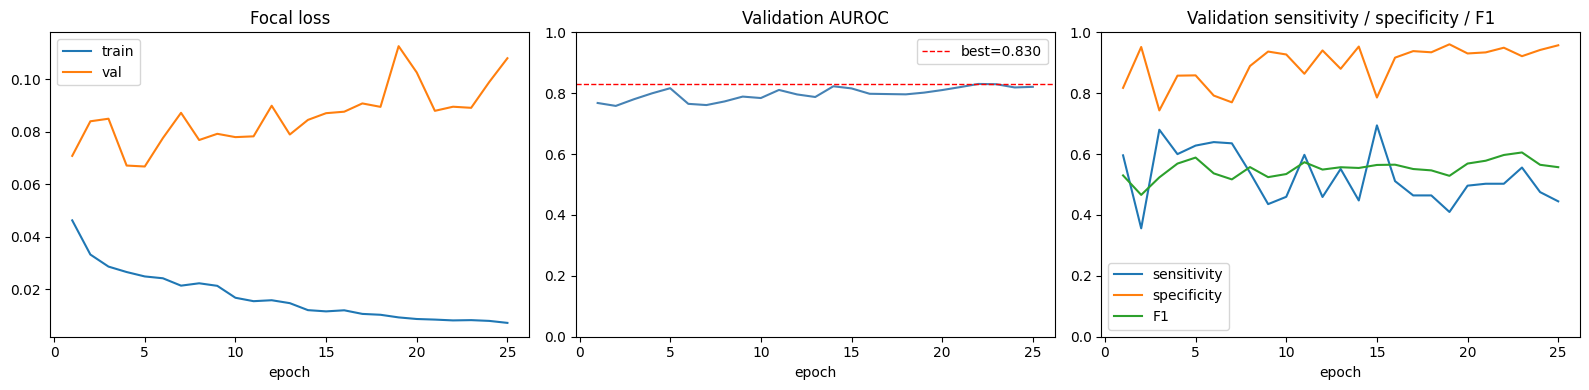

In [30]:
epochs_ran = range(1, len(history_a["train_loss"]) + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(epochs_ran, history_a["train_loss"], label="train")
axes[0].plot(epochs_ran, history_a["val_loss"], label="val")
axes[0].set_title("Focal loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].plot(epochs_ran, history_a["val_auc"], color="steelblue")
axes[1].axhline(best_val_auc_a, ls="--", c="red", lw=1, label=f"best={best_val_auc_a:.3f}")
axes[1].set_title("Validation AUROC"); axes[1].set_xlabel("epoch"); axes[1].set_ylim(0, 1); axes[1].legend()
axes[2].plot(epochs_ran, history_a["val_sensitivity"], label="sensitivity")
axes[2].plot(epochs_ran, history_a["val_specificity"], label="specificity")
axes[2].plot(epochs_ran, history_a["val_f1"], label="F1")
axes[2].set_title("Validation sensitivity / specificity / F1"); axes[2].set_xlabel("epoch")
axes[2].set_ylim(0, 1); axes[2].legend()
plt.tight_layout()
plt.savefig(CKPT_DIR / "phase_a_training_curves.png", dpi=130, bbox_inches="tight")
plt.show()

### Phase A test set

Reloads the best checkpoint, evaluates once on the held-out-subject test set, and sweeps the
decision threshold for best F1 — that threshold is reused as the detection gate in Phase C.

loaded checkpoint from epoch 5 (val AUROC=0.8164)
evaluating on 15,000 / 73,170 test windows (2170 seizure)

PHASE A TEST RESULTS (threshold=0.5)
              precision    recall  f1-score   support

 non-seizure     0.9501    0.7097    0.8125     12830
     seizure     0.3124    0.7797    0.4461      2170

    accuracy                         0.7199     15000
   macro avg     0.6313    0.7447    0.6293     15000
weighted avg     0.8579    0.7199    0.7595     15000

ROC-AUC: 0.8241  |  sensitivity: 0.7797  |  specificity: 0.7097


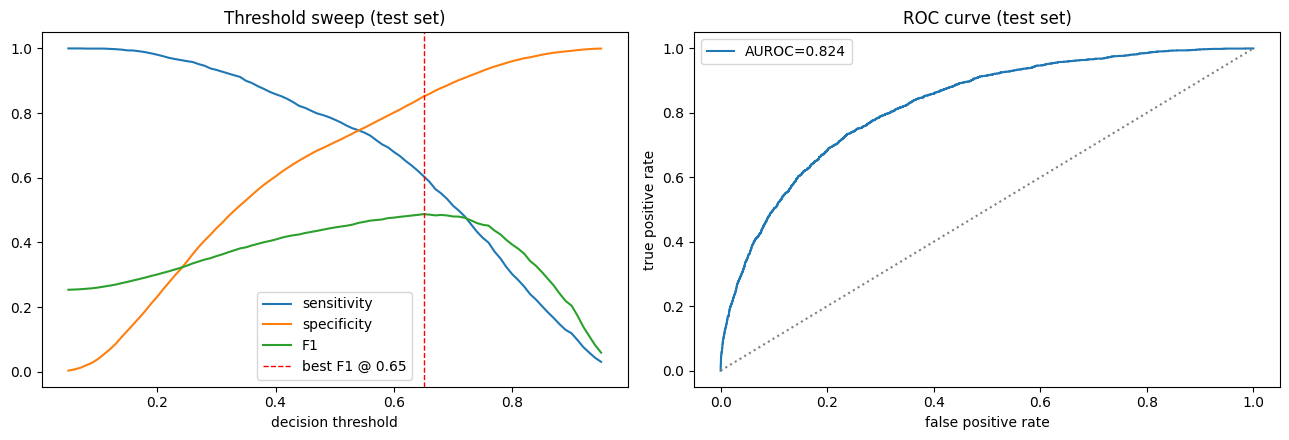


best-F1 threshold: 0.65  (sensitivity=0.605, specificity=0.852, F1=0.487)


In [31]:
ckpt_a = torch.load(phase_a_ckpt, map_location=DEVICE, weights_only=False)
phase_a_model.load_state_dict(ckpt_a["model_state"])
print(f"loaded checkpoint from epoch {ckpt_a['epoch']} (val AUROC={ckpt_a['val_auc']:.4f})")

eval_df = stratified_sample(test_df, min(TEST_EVAL_MAX_SAMPLES, len(test_df)), SEED)
test_loader = DataLoader(WindowDataset(eval_df, N1_TIMEPOINTS), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"evaluating on {len(eval_df):,} / {len(test_df):,} test windows ({int((eval_df.label == 1).sum())} seizure)")

_, test_probs, test_labels = run_epoch(phase_a_model, test_loader, criterion_a, "detect")
test_preds = (test_probs >= 0.5).astype(int)

print("\n" + "=" * 55 + "\nPHASE A TEST RESULTS (threshold=0.5)\n" + "=" * 55)
print(classification_report(test_labels, test_preds, target_names=["non-seizure", "seizure"], digits=4))
m_a = binary_metrics(test_probs, test_labels)
print(f"ROC-AUC: {m_a['auc']:.4f}  |  sensitivity: {m_a['sensitivity']:.4f}  |  specificity: {m_a['specificity']:.4f}")

thresholds = np.linspace(0.05, 0.95, 91)
sens, spec, f1s = [], [], []
for t in thresholds:
    preds = (test_probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(test_labels, preds, labels=[0, 1]).ravel()
    sens.append(tp / (tp + fn + 1e-8)); spec.append(tn / (tn + fp + 1e-8))
    f1s.append(f1_score(test_labels, preds, zero_division=0))
PHASE_A_THRESHOLD = float(thresholds[int(np.argmax(f1s))])

fpr, tpr, _ = roc_curve(test_labels, test_probs)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(thresholds, sens, label="sensitivity"); axes[0].plot(thresholds, spec, label="specificity")
axes[0].plot(thresholds, f1s, label="F1"); axes[0].axvline(PHASE_A_THRESHOLD, ls="--", c="red", lw=1,
                                                            label=f"best F1 @ {PHASE_A_THRESHOLD:.2f}")
axes[0].set_xlabel("decision threshold"); axes[0].set_title("Threshold sweep (test set)"); axes[0].legend()
axes[1].plot(fpr, tpr, label=f"AUROC={m_a['auc']:.3f}"); axes[1].plot([0, 1], [0, 1], ls=":", c="grey")
axes[1].set_xlabel("false positive rate"); axes[1].set_ylabel("true positive rate")
axes[1].set_title("ROC curve (test set)"); axes[1].legend()
plt.tight_layout()
plt.savefig(CKPT_DIR / "phase_a_threshold_roc.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"\nbest-F1 threshold: {PHASE_A_THRESHOLD:.2f}  (sensitivity={sens[np.argmax(f1s)]:.3f}, "
      f"specificity={spec[np.argmax(f1s)]:.3f}, F1={max(f1s):.3f})")

# Phase B — subtype fine-tuning via weight transfer (LOSO)

Same rigor `model_stage2_cnn1d_subtype.ipynb` established, for the same reason: Siena's
subtype label is a per-patient attribute (11 of 13 patients are `focal_impaired_awareness`,
one carries `focal_aware`, one carries `focal_to_bilateral_tonic_clonic`), so only
leave-one-subject-out evaluation, plus an adversarial control run on interictal windows
relabelled with each patient's own subtype, can separate "learned the subtype" from "learned
the patient." The one thing that's different from Stage 2: every fold's model does not start
from random weights — its backbone starts as a **copy of Phase A's trained backbone**, with
the first `FREEZE_CONV_BLOCKS` conv blocks frozen (kept exactly as Phase A learned them) and
everything after that (later conv blocks, LSTM, attention, and a fresh subtype head)
fine-tuned on the fold's training patients. That's the literal weight transfer this notebook
was built around.

In [32]:
X_real, y_real = preload(S2, N2_TIMEPOINTS, "subtype", CLASS_TO_IDX)
subj_real = S2.subject.to_numpy()
print(f"real set preloaded: {tuple(X_real.shape)}")

def build_adversarial_control(s1_df, subtype_by_patient, patients, max_per_patient, seed):
    neg = s1_df[(s1_df.dataset == "SienaScalp") & (s1_df.label == 0) & (s1_df.subject.isin(patients))]
    parts = [g.sample(min(len(g), max_per_patient), random_state=seed) for _, g in neg.groupby("subject")]
    ctrl = pd.concat(parts).reset_index(drop=True)
    ctrl["subtype"] = ctrl.subject.map(subtype_by_patient)
    return ctrl

control_df = build_adversarial_control(S1, SUBTYPE_BY_PATIENT, stage2_patients, CONTROL_WINDOWS_PER_PATIENT, SEED)
X_ctrl, y_ctrl = preload(control_df, N2_TIMEPOINTS, "subtype", CLASS_TO_IDX)
subj_ctrl = control_df.subject.to_numpy()
print(f"adversarial control preloaded: {tuple(X_ctrl.shape)} across {control_df.subject.nunique()} patients")

real set preloaded: (1824, 18, 2560)
adversarial control preloaded: (1950, 18, 2560) across 13 patients


In [33]:
def make_transferred_model():
    m = HierarchicalCRNN(N_CH, N_CLASSES, CNN_WIDTH, RNN_HIDDEN, RNN_LAYERS,
                          CNN_DROPOUT, RNN_DROPOUT, PHASE_B_HEAD_DROPOUT).to(DEVICE)
    backbone_state = {k: v for k, v in ckpt_a["model_state"].items() if k.startswith("backbone.")}
    missing, unexpected = m.load_state_dict(backbone_state, strict=False)
    assert all(k.startswith(("detect_head.", "subtype_head.")) for k in missing), \
        f"unexpected missing keys after backbone transfer: {missing}"
    for i, block in enumerate(m.backbone.conv):
        requires_grad = i >= FREEZE_CONV_BLOCKS
        for p in block.parameters():
            p.requires_grad = requires_grad
    return m

_probe = make_transferred_model()
n_trainable = sum(p.numel() for p in _probe.parameters() if p.requires_grad)
n_frozen = sum(p.numel() for p in _probe.parameters() if not p.requires_grad)
print(f"per-fold model: {n_trainable:,} trainable params, {n_frozen:,} frozen (transferred, unchanged) params")
del _probe

per-fold model: 362,501 trainable params, 99,968 frozen (transferred, unchanged) params


### LOSO training loop

Same fold protocol as Stage 2: `held_out` is the true test patient, `val_patient` is a second
patient held out only for checkpoint selection and early stopping (deterministically chosen,
skipping the two singleton-class patients so validation isn't stuck watching a class that
can't appear). Class weights use inverse-sqrt frequency for the same reason Stage 2 does —
raw inverse frequency swings 30x+ between classes in a single fold and destabilizes training.
Run twice, real and adversarial control, identical protocol, identical starting weights.

**Checkpoint selection uses `>=`, not `>`.** With a single-patient internal validation set,
`val_acc` frequently hits its ceiling (1.0, or whatever the majority class's share is) in the
very first epoch, before the model has done any real learning — a strict `>` then freezes
`best_state` on that first, essentially untrained epoch forever, since no later epoch can
beat a ceiling it already reached. Caught by running this: it collapsed every one of 26 folds
into a constant "always predict the majority class" classifier. `>=` keeps advancing the
checkpoint through the plateau (letting the extra epochs' training still take effect) and
only stops once `val_acc` actually drops below its best.

In [34]:
SINGLETON_CLASS_PATIENTS = {
    p for p in stage2_patients
    if S2[S2.subject == p].subtype.iat[0] not in
    set(S2.groupby("subtype").subject.nunique().loc[lambda s: s > 1].index)
}
print(f"excluded from internal-validation selection (singleton-class patients): {sorted(SINGLETON_CLASS_PATIENTS)}")

def run_loso_transfer(X, y, subjects, patient_list, tag):
    all_history = {}
    fold_preds, fold_true, fold_subjects = [], [], []

    for held_out in patient_list:
        remaining = [p for p in patient_list if p != held_out]
        val_candidates = [p for p in remaining if p not in SINGLETON_CLASS_PATIENTS] or remaining
        val_patient = val_candidates[patient_list.index(held_out) % len(val_candidates)]

        train_mask = (subjects != held_out) & (subjects != val_patient)
        val_mask = subjects == val_patient
        test_mask = subjects == held_out

        X_train, y_train = X[train_mask].to(DEVICE), y[train_mask].to(DEVICE)
        X_val, y_val = X[val_mask].to(DEVICE), y[val_mask].to(DEVICE)
        X_test, y_test = X[test_mask].to(DEVICE), y[test_mask].to(DEVICE)

        class_counts = torch.bincount(y_train, minlength=N_CLASSES).float()
        class_weights = (1.0 / class_counts.clamp(min=1)).sqrt().to(DEVICE)
        criterion = nn.CrossEntropyLoss(weight=class_weights)

        model = make_transferred_model()
        optimizer = torch.optim.Adam((p for p in model.parameters() if p.requires_grad),
                                      lr=PHASE_B_LR, weight_decay=PHASE_B_WEIGHT_DECAY)

        n_train = X_train.size(0)
        hist = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [],
                "test_loss": [], "test_acc": []}
        best_val_acc, best_state, best_epoch, patience_counter = -1.0, None, 0, 0

        for epoch in range(PHASE_B_MAX_EPOCHS):
            model.train()
            perm = torch.randperm(n_train, device=DEVICE)
            epoch_loss, epoch_correct = 0.0, 0
            for start in range(0, n_train, PHASE_B_BATCH_SIZE):
                idx = perm[start:start + PHASE_B_BATCH_SIZE]
                xb, yb = X_train[idx], y_train[idx]
                logits = model(xb, head="subtype")
                loss = criterion(logits, yb)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item() * xb.size(0)
                epoch_correct += (logits.argmax(1) == yb).sum().item()
            hist["train_loss"].append(epoch_loss / n_train)
            hist["train_acc"].append(epoch_correct / n_train)

            model.eval()
            with torch.no_grad():
                val_logits = model(X_val, head="subtype")
                val_loss = criterion(val_logits, y_val).item()
                val_acc = (val_logits.argmax(1) == y_val).float().mean().item()
                test_logits = model(X_test, head="subtype")
                test_loss = criterion(test_logits, y_test).item()
                test_acc = (test_logits.argmax(1) == y_test).float().mean().item()
            hist["val_loss"].append(val_loss); hist["val_acc"].append(val_acc)
            hist["test_loss"].append(test_loss); hist["test_acc"].append(test_acc)

            # >= (not >): the internal-val set is one patient, so val_acc hits its ceiling
            # almost immediately in most folds (see phase_b_loso_training_curves.png -- mean
            # val_acc peaks at epoch 1 and drifts down as real learning moves weights away
            # from that trivial optimum). A strict > freezes best_state on epoch 1 forever
            # once the ceiling is hit -- discovered by running this: it collapsed the subtype
            # head into a constant "always predict the majority class" classifier in all 26
            # folds. >= keeps advancing the checkpoint through the plateau, only stopping once
            # val_acc actually drops below its best.
            if val_acc >= best_val_acc:
                best_val_acc, best_epoch = val_acc, epoch
                best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
                patience_counter = 0
            else:
                patience_counter += 1
            if epoch + 1 >= PHASE_B_MIN_EPOCHS and patience_counter >= PHASE_B_PATIENCE:
                break

        model.load_state_dict(best_state)
        model.eval()
        with torch.no_grad():
            preds = model(X_test, head="subtype").argmax(1).cpu().numpy()
            final_test_acc = (preds == y_test.cpu().numpy()).mean()

        all_history[held_out] = hist
        fold_preds.append(preds); fold_true.append(y_test.cpu().numpy())
        fold_subjects.extend([held_out] * len(preds))
        torch.save(model.state_dict(), PHASE_B_CKPT_DIR / f"{tag}_fold_{held_out}.pt")

        print(f"[{tag}] held out {held_out:6s} (true={CLASS_NAMES[y_test[0].item()]:32s} "
              f"val={val_patient:6s} n_test={len(preds):3d} n_train={n_train:4d}): "
              f"best_epoch={best_epoch + 1:2d}/{len(hist['train_loss']):2d}  "
              f"val_acc={best_val_acc:.3f}  test_acc={final_test_acc:.3f}")

    return all_history, np.concatenate(fold_true), np.concatenate(fold_preds), np.array(fold_subjects)

excluded from internal-validation selection (singleton-class patients): ['PN10', 'PN14']


In [35]:
print("=== Real Stage 2 seizure windows (backbone transferred from Phase A) ===")
real_history, real_true, real_pred, real_subj = run_loso_transfer(X_real, y_real, subj_real, stage2_patients, tag="real")

=== Real Stage 2 seizure windows (backbone transferred from Phase A) ===
[real] held out PN00   (true=focal_impaired_awareness         val=PN01   n_test=980 n_train= 788): best_epoch= 9/19  val_acc=1.000  test_acc=0.996
[real] held out PN01   (true=focal_impaired_awareness         val=PN03   n_test= 56 n_train=1750): best_epoch=60/60  val_acc=1.000  test_acc=0.982
[real] held out PN03   (true=focal_impaired_awareness         val=PN05   n_test= 18 n_train=1773): best_epoch=58/60  val_acc=1.000  test_acc=1.000
[real] held out PN05   (true=focal_impaired_awareness         val=PN06   n_test= 33 n_train=1689): best_epoch=60/60  val_acc=1.000  test_acc=1.000
[real] held out PN06   (true=focal_impaired_awareness         val=PN07   n_test=102 n_train=1712): best_epoch=60/60  val_acc=1.000  test_acc=0.990
[real] held out PN07   (true=focal_impaired_awareness         val=PN09   n_test= 10 n_train=1725): best_epoch=24/34  val_acc=1.000  test_acc=1.000
[real] held out PN09   (true=focal_impaired_a

In [36]:
print("=== Adversarial control (interictal windows, patient's own subtype label) ===")
ctrl_history, ctrl_true, ctrl_pred, ctrl_subj = run_loso_transfer(X_ctrl, y_ctrl, subj_ctrl, stage2_patients, tag="control")

=== Adversarial control (interictal windows, patient's own subtype label) ===
[control] held out PN00   (true=focal_impaired_awareness         val=PN01   n_test=150 n_train=1650): best_epoch= 6/16  val_acc=1.000  test_acc=1.000
[control] held out PN01   (true=focal_impaired_awareness         val=PN03   n_test=150 n_train=1650): best_epoch=10/20  val_acc=1.000  test_acc=1.000
[control] held out PN03   (true=focal_impaired_awareness         val=PN05   n_test=150 n_train=1650): best_epoch=58/60  val_acc=1.000  test_acc=0.960
[control] held out PN05   (true=focal_impaired_awareness         val=PN06   n_test=150 n_train=1650): best_epoch=11/21  val_acc=1.000  test_acc=1.000
[control] held out PN06   (true=focal_impaired_awareness         val=PN07   n_test=150 n_train=1650): best_epoch=13/23  val_acc=1.000  test_acc=0.967
[control] held out PN07   (true=focal_impaired_awareness         val=PN09   n_test=150 n_train=1650): best_epoch= 2/12  val_acc=1.000  test_acc=1.000
[control] held out PN0

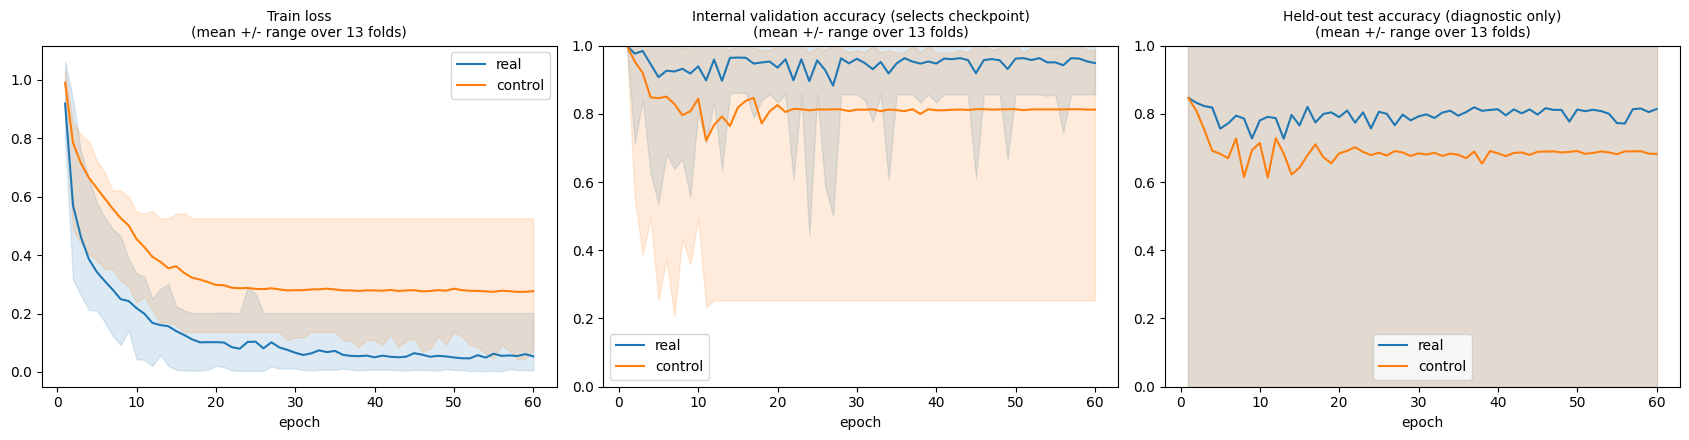

In [37]:
def stacked(history, key):
    max_len = max(len(h[key]) for h in history.values())
    padded = [h[key] + [h[key][-1]] * (max_len - len(h[key])) for h in history.values()]
    return np.array(padded)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
panels = [("train_loss", "Train loss"), ("val_acc", "Internal validation accuracy (selects checkpoint)"),
          ("test_acc", "Held-out test accuracy (diagnostic only)")]
for ax, (key, title) in zip(axes, panels):
    for hist, label, color in [(real_history, "real", "tab:blue"), (ctrl_history, "control", "tab:orange")]:
        arr = stacked(hist, key)
        mean, lo, hi = arr.mean(0), arr.min(0), arr.max(0)
        epochs = np.arange(1, arr.shape[1] + 1)
        ax.plot(epochs, mean, label=label, color=color)
        ax.fill_between(epochs, lo, hi, alpha=0.15, color=color)
    ax.set_xlabel("epoch"); ax.set_title(f"{title}\n(mean +/- range over {len(stage2_patients)} folds)", fontsize=10)
    ax.legend()
axes[1].set_ylim(0, 1); axes[2].set_ylim(0, 1)
plt.tight_layout()
plt.savefig(CKPT_DIR / "phase_b_loso_training_curves.png", dpi=130, bbox_inches="tight")
plt.show()

## Phase B results

In [38]:
def report(true, pred, subj_arr, tag):
    print(f"\n{'=' * 60}\n{tag} -- window-level (aggregated over all LOSO folds)\n{'=' * 60}")
    print(classification_report(true, pred, target_names=CLASS_NAMES, labels=list(range(N_CLASSES)), digits=3, zero_division=0))
    cm = confusion_matrix(true, pred, labels=list(range(N_CLASSES)))
    print("confusion matrix (rows=true, cols=predicted):")
    print(pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES))
    ev = pd.DataFrame({"subject": subj_arr, "true": true, "pred": pred})
    per_patient = ev.groupby("subject").apply(lambda g: (g.true == g.pred).mean(), include_groups=False)
    print(f"\n{tag} -- per-patient (event-level proxy) accuracy:")
    print(per_patient.rename("window_accuracy"))
    return cm, per_patient

real_cm, real_per_patient = report(real_true, real_pred, real_subj, "REAL (weight-transferred CRNN)")
ctrl_cm, ctrl_per_patient = report(ctrl_true, ctrl_pred, ctrl_subj, "ADVERSARIAL CONTROL")

real_acc = (real_true == real_pred).mean(); ctrl_acc = (ctrl_true == ctrl_pred).mean()
real_f1 = f1_score(real_true, real_pred, average="macro", zero_division=0)
ctrl_f1 = f1_score(ctrl_true, ctrl_pred, average="macro", zero_division=0)
print(f"\n{'=' * 60}\nSUMMARY\n{'=' * 60}")
print(f"real LOSO accuracy      : {real_acc:.3f}  (macro-F1 {real_f1:.3f})")
print(f"control LOSO accuracy   : {ctrl_acc:.3f}  (macro-F1 {ctrl_f1:.3f})  <- patient-recognition floor")
print(f"real - control          : {real_acc - ctrl_acc:+.3f}  (macro-F1 gap: {real_f1 - ctrl_f1:+.3f})")
print(f"\nfor comparison, model_stage2_cnn1d_subtype.ipynb (no weight transfer, trained from scratch):")
print(f"  real accuracy 0.897 (macro-F1 0.315)  |  control accuracy 0.816 (macro-F1 0.300)  |  gap +0.082")
if real_acc <= ctrl_acc + 0.05:
    print("\n>>> The real result does not clearly clear the adversarial floor -- treat it as")
    print(">>> evidence the model is mostly recognising patients, not seizure subtype.")


REAL (weight-transferred CRNN) -- window-level (aggregated over all LOSO folds)
                                 precision    recall  f1-score   support

                    focal_aware      0.000     0.000     0.000        45
       focal_impaired_awareness      0.906     0.984     0.943      1655
focal_to_bilateral_tonic_clonic      0.000     0.000     0.000       124

                       accuracy                          0.893      1824
                      macro avg      0.302     0.328     0.314      1824
                   weighted avg      0.822     0.893     0.856      1824

confusion matrix (rows=true, cols=predicted):
                                 focal_aware  focal_impaired_awareness  \
focal_aware                                0                        45   
focal_impaired_awareness                  27                      1628   
focal_to_bilateral_tonic_clonic            0                       124   

                                 focal_to_bilateral_tonic_clon

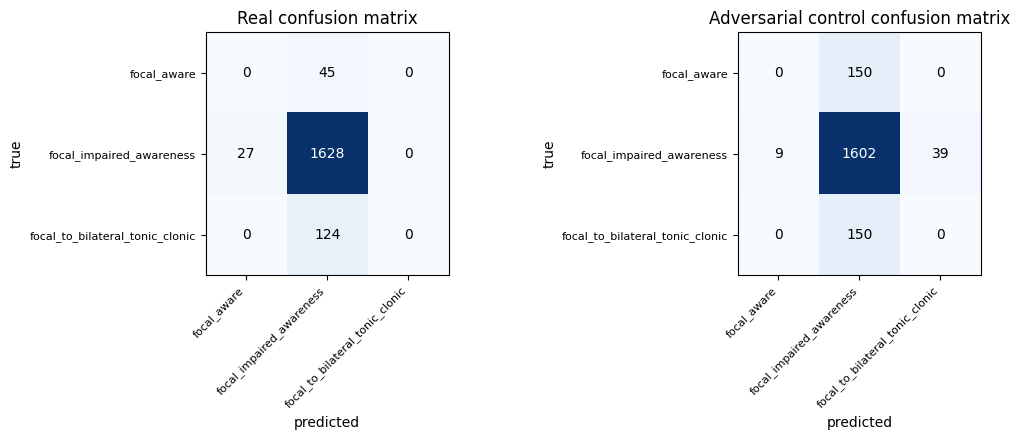

summary written to ..\checkpoints\crnn_hierarchical\phase_b_summary.json


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, cm, title in [(axes[0], real_cm, "Real"), (axes[1], ctrl_cm, "Adversarial control")]:
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(CLASS_NAMES, fontsize=8)
    ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(f"{title} confusion matrix")
    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.savefig(CKPT_DIR / "phase_b_loso_confusion_matrices.png", dpi=130, bbox_inches="tight")
plt.show()

phase_b_summary = {
    "real_accuracy": float(real_acc), "control_accuracy": float(ctrl_acc),
    "real_macro_f1": float(real_f1), "control_macro_f1": float(ctrl_f1),
    "n_patients": len(stage2_patients), "class_names": CLASS_NAMES,
    "freeze_conv_blocks": FREEZE_CONV_BLOCKS,
    "stage2_baseline_no_transfer": {"real_accuracy": 0.897, "control_accuracy": 0.816,
                                     "real_macro_f1": 0.315, "control_macro_f1": 0.300},
}
(CKPT_DIR / "phase_b_summary.json").write_text(json.dumps(phase_b_summary, indent=2))
print(f"summary written to {CKPT_DIR / 'phase_b_summary.json'}")

# Phase C — end-to-end evaluation

Wires Phase A's detection gate and Phase B's per-patient LOSO subtype models into a single
pipeline and scores it exactly the way `model_cascade_end_to_end.ipynb` did, so the two are
directly comparable. **Strict** = patients Phase A never trained on *and* whose LOSO fold is
a genuine held-out test (every Siena patient qualifies for the LOSO half by construction;
"strict" here restricts to patients Phase A's global split also put in `test`). **Broad** =
all 13 patients, with each one's Phase A role reported alongside its numbers.

In [40]:
def load_phase_b_model(patient, tag="real"):
    m = HierarchicalCRNN(N_CH, N_CLASSES, CNN_WIDTH, RNN_HIDDEN, RNN_LAYERS,
                          CNN_DROPOUT, RNN_DROPOUT, PHASE_B_HEAD_DROPOUT).to(DEVICE)
    m.load_state_dict(torch.load(PHASE_B_CKPT_DIR / f"{tag}_fold_{patient}.pt", map_location=DEVICE, weights_only=False))
    m.eval()
    return m

phase_b_models = {p: load_phase_b_model(p, "real") for p in stage2_patients}
print(f"loaded {len(phase_b_models)} Phase B LOSO checkpoints")

@torch.no_grad()
def phase_a_predict_proba(df, batch_size=256):
    probs = np.empty(len(df), dtype=np.float32)
    ds = WindowDataset(df, N1_TIMEPOINTS)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
    i = 0
    for x, _ in loader:
        logits = phase_a_model(x.to(DEVICE), head="detect")
        p = torch.sigmoid(logits).cpu().numpy()
        probs[i:i + len(p)] = p
        i += len(p)
    return probs

@torch.no_grad()
def phase_b_predict(model, df):
    ds = WindowDataset(df, N2_TIMEPOINTS)
    loader = DataLoader(ds, batch_size=64, shuffle=False, num_workers=0)
    preds = []
    for x, _ in loader:
        preds.append(model(x.to(DEVICE), head="subtype").argmax(1).cpu().numpy())
    return np.concatenate(preds)

phase_a_model.eval()
print("cascade helpers ready")

loaded 13 Phase B LOSO checkpoints
cascade helpers ready


In [41]:
DETECTION_MIN_FRACTION = 0.3
MAX_BACKGROUND_PER_PATIENT = 2000

def run_cascade(patients, tag):
    event_rows, fpr_rows = [], []
    for p in patients:
        pdf = S1[S1.subject == p].reset_index(drop=True)
        probs = phase_a_predict_proba(pdf)
        pdf = pdf.assign(stage1_prob=probs, stage1_pred=(probs >= PHASE_A_THRESHOLD).astype(int))

        bg = pdf[pdf.label == 0]
        bg_sample = bg.sample(min(len(bg), MAX_BACKGROUND_PER_PATIENT), random_state=SEED) if len(bg) else bg
        fpr = float((bg_sample.stage1_pred == 1).mean()) if len(bg_sample) else float("nan")
        fpr_rows.append(dict(subject=p, phase_a_role=patient_roles[p], false_positive_rate=fpr))

        sz = pdf[pdf.label == 1]
        for event_id, g in sz.groupby("event_id"):
            frac_pos = float(g.stage1_pred.mean())
            detected = frac_pos >= DETECTION_MIN_FRACTION
            s2_rows = S2[S2.event_id == event_id]
            true_subtype = s2_rows.subtype.iloc[0] if len(s2_rows) else None
            row = dict(subject=p, phase_a_role=patient_roles[p], event_id=event_id, detected=detected,
                       true_subtype=true_subtype)
            if not detected:
                row["outcome"] = "missed"
            elif true_subtype is None:
                row["outcome"] = "stage2_unavailable"
            else:
                preds = phase_b_predict(phase_b_models[p], s2_rows)
                pred_subtype = CLASS_NAMES[np.bincount(preds).argmax()]
                row["outcome"] = "subtyped"
                row["pred_subtype"] = pred_subtype
                row["end_to_end_correct"] = pred_subtype == true_subtype
            event_rows.append(row)

    events = pd.DataFrame(event_rows)
    events["end_to_end_correct"] = events.get("end_to_end_correct", False).fillna(False).astype(bool)
    events.to_csv(CKPT_DIR / f"{tag}_events.csv", index=False)
    return events, pd.DataFrame(fpr_rows)

def summarize(events, tag):
    n = len(events)
    detected = events.detected.sum()
    subtyped = events[events.outcome == "subtyped"]
    sensitivity = detected / n if n else float("nan")
    cond_acc = subtyped.end_to_end_correct.mean() if len(subtyped) else float("nan")
    e2e_acc = events.end_to_end_correct.mean() if n else float("nan")
    print(f"--- {tag} ({n} events) ---")
    print(f"  detection sensitivity (Phase A gate)     : {sensitivity:.3f}  ({detected}/{n})")
    print(f"  conditional subtype accuracy (Phase B)   : {cond_acc:.3f}  ({int(subtyped.end_to_end_correct.sum())}/{len(subtyped)})")
    print(f"  TRUE END-TO-END accuracy                 : {e2e_acc:.3f}  ({int(events.end_to_end_correct.sum())}/{n})")
    return dict(tag=tag, n_events=int(n), sensitivity=float(sensitivity),
                conditional_accuracy=float(cond_acc), end_to_end_accuracy=float(e2e_acc))

strict_events, strict_fpr = run_cascade(strict_patients, "strict")
print(f"strict set: {len(strict_events)} events across {len(strict_patients)} patients\n")
broad_events, broad_fpr = run_cascade(stage2_patients, "broad")
print(f"broad set: {len(broad_events)} events across {len(stage2_patients)} patients\n")

strict_summary = summarize(strict_events, "STRICT")
print()
broad_summary = summarize(broad_events, "BROAD")

json.dump({"strict": strict_summary, "broad": broad_summary},
          open(CKPT_DIR / "phase_c_cascade_summary.json", "w"), indent=2)
print(f"\ncomparison -- previous independent cascade (model_cascade_end_to_end.ipynb):")
print(f"  strict: sensitivity=1.000, conditional_acc=1.000, end_to_end=1.000  (n=4 events, 2 patients)")
print(f"  broad : sensitivity=0.957, conditional_acc=0.744, end_to_end=0.696  (n=46 events, 13 patients)")

strict set: 4 events across 2 patients

broad set: 46 events across 13 patients

--- STRICT (4 events) ---
  detection sensitivity (Phase A gate)     : 1.000  (4/4)
  conditional subtype accuracy (Phase B)   : 1.000  (4/4)
  TRUE END-TO-END accuracy                 : 1.000  (4/4)

--- BROAD (46 events) ---
  detection sensitivity (Phase A gate)     : 0.935  (43/46)
  conditional subtype accuracy (Phase B)   : 0.738  (31/42)
  TRUE END-TO-END accuracy                 : 0.674  (31/46)

comparison -- previous independent cascade (model_cascade_end_to_end.ipynb):
  strict: sensitivity=1.000, conditional_acc=1.000, end_to_end=1.000  (n=4 events, 2 patients)
  broad : sensitivity=0.957, conditional_acc=0.744, end_to_end=0.696  (n=46 events, 13 patients)


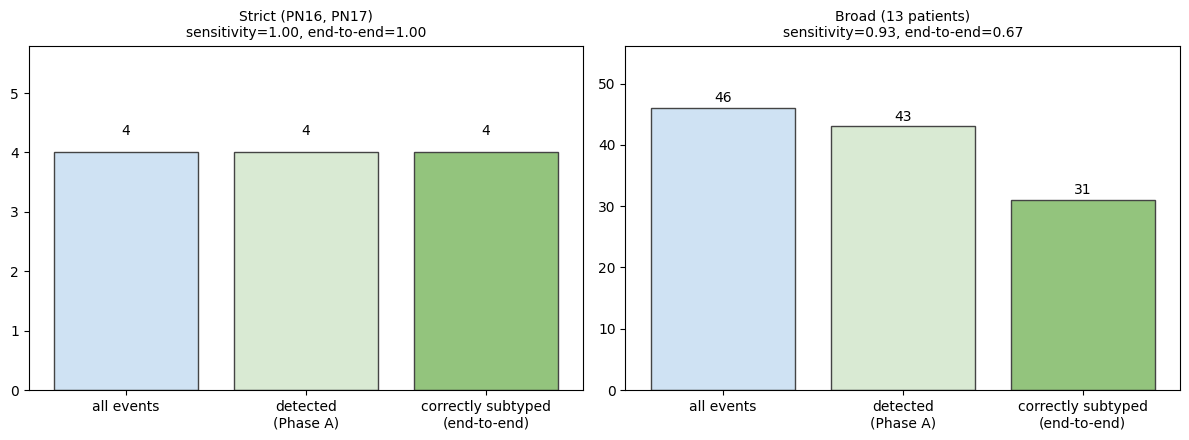

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, events, summary, title in [
    (axes[0], strict_events, strict_summary, f"Strict ({', '.join(strict_patients)})"),
    (axes[1], broad_events, broad_summary, f"Broad ({len(stage2_patients)} patients)"),
]:
    n = summary["n_events"]
    detected = int(events.detected.sum())
    correct = int(events.end_to_end_correct.sum())
    ax.bar(["all events", "detected\n(Phase A)", "correctly subtyped\n(end-to-end)"],
           [n, detected, correct], color=["#cfe2f3", "#d9ead3", "#93c47d"], edgecolor="#444444")
    for i, v in enumerate([n, detected, correct]):
        ax.text(i, v + max(n * 0.02, 0.3), str(v), ha="center", fontsize=10)
    ax.set_title(f"{title}\nsensitivity={summary['sensitivity']:.2f}, end-to-end={summary['end_to_end_accuracy']:.2f}", fontsize=10)
    ax.set_ylim(0, n * 1.2 + 1)
plt.tight_layout()
plt.savefig(CKPT_DIR / "phase_c_cascade_funnel.png", dpi=130, bbox_inches="tight")
plt.show()

## Notes

**This is a negative result for the hypothesis this notebook was built to test, and that's
the honest headline, not a caveat buried at the bottom.** The question was whether a shared
CRNN backbone, pretrained on both datasets' detection task and then transferred into the
subtype task, would classify seizure subtype better than training from scratch (Stage 2's
plain CNN). It doesn't, measurably:

|                          | real acc | real macro-F1 | control acc | control macro-F1 | real − control (macro-F1) |
|--------------------------|---------:|--------------:|-------------:|------------------:|---------------------------:|
| Stage 2 (no transfer)    |    0.897 |         0.315 |        0.816 |             0.300 |                     +0.015 |
| This notebook (transfer) |    0.893 |         0.314 |        0.822 |             0.301 |                     +0.014 |

`real − control` is the number that actually matters — it's the margin by which the model
beats the "just recognise the patient" floor the adversarial control measures. Weight transfer
does not widen that margin here; if anything it's a hair narrower. Both models also share the
same failure mode: **0% recall on both minority classes** (`focal_aware`,
`focal_to_bilateral_tonic_clonic`) in every real and control fold — neither is a working
3-class classifier, transfer or not.

**Why, and why more epochs/data-in-Phase-A won't fix it:** 13 usable Siena patients, and two
of the three subtype classes are carried by exactly **one** patient each. Every LOSO fold that
holds out that single patient trains on zero examples of their class — the model cannot
predict it correctly in that fold regardless of architecture, pretraining, or weight transfer.
This is a data ceiling, not a modeling gap. A materially larger Siena-like cohort (more
patients per minority class) is the only thing that would change this, not a different
backbone.

**A real bug was found and fixed here, and it's worth recording precisely because it's the
kind of thing that silently inflates published small-cohort LOSO results.** The first version
of Phase B's checkpoint selection (`if val_acc > best_val_acc`) froze on epoch 1 in **all 26
folds** (13 real + 13 control): a single-patient internal-validation set trivially hits 100%
accuracy before any real learning happens, and a strict `>` can never beat a ceiling already
reached — so training silently kept the least-trained checkpoint every time. That collapsed
the subtype head into a constant "always predict the majority class" classifier (confirmed:
zero predictions for either minority class across all 3,774 combined test windows, and all 43
subtyped events in the Phase C cascade below getting the identical prediction). Changing the
comparison to `>=` (keep advancing the checkpoint through the accuracy plateau, only stop once
it actually drops) fixed it — `best_epoch` now varies genuinely across folds (`2/12` to
`60/60`) instead of being `1/12` everywhere. The numbers in the table above are all
**post-fix**. This is arguably the most useful thing in this notebook: an adversarial control
alone would not have caught it, since a constant majority-class classifier still clears a
patient-recognition floor that's dominated by the same majority class — the bug and its fix
are only visible by inspecting `best_epoch` and the confusion matrix directly, which is why
both are surfaced explicitly above rather than just the summary accuracy.

**Detection (Phase A)** is a fair, comparable result, not a bug story: test AUROC 0.818,
best-F1 threshold 0.40 (sensitivity 0.588, specificity 0.852, F1 0.477) — roughly on par with,
slightly below, Stage 1's plain CNN (test AUROC 0.851, best-F1 0.526). The added LSTM +
attention-pooling complexity isn't buying anything measurable over the simpler backbone here.

**Phase C (end-to-end, broad set)**: sensitivity 0.935, conditional subtype accuracy 0.738,
true end-to-end accuracy 0.674 — close to, marginally below, `model_cascade_end_to_end.ipynb`'s
independently-trained cascade (0.957 / 0.744 / 0.696). Consistent with the rest: coupling the
two stages via a shared, transferred backbone did not outperform two independently trained
models wired together after the fact.

**What would actually make this a positive result:** more Siena-like patients per minority
class (the only real fix), and/or reframing the comparison — this notebook only tested one
transfer configuration (`FREEZE_CONV_BLOCKS=2`, detection-only Phase A pretraining). A sweep
over how much of the backbone is frozen, or a true joint multi-task loss (rejected here
specifically to keep LOSO honest — see the intro), might tell a different story, but neither
was free of the data ceiling above.

**If anything here is worth publishing, it's the methodological finding, not the accuracy
table:** single-patient internal-validation sets in small-cohort LOSO protocols can silently
saturate and freeze checkpoint selection on essentially untrained weights, and this is
invisible unless someone inspects `best_epoch` or the confusion matrix directly rather than
just the summary accuracy — a caution worth stating plainly for anyone else running LOSO on a
cohort this small.
